# **Actividad - Clasificación**
Caso 5 - Laura Chavarriaga, Natalia Mejía y Juan Pablo Monsalve

## **1. Entendimiento del negocio**
Una organización financiera requiere estimar el rango de ingresos de clientes potenciales cuando esta información no está disponible, es incompleta o puede no ser totalmente confiable. Contar con esta estimación permite mejorar la segmentación comercial, priorizar prospectos con mayor probabilidad de adquirir productos y diseñar campañas más efectivas para ofertas. 

## **2. Enfoque analítico**
Desarrollar un experimento de clasificación para determinar rangos de ingresos en una población de diferentes edades con un desempeño esperado mayor al 85%.

## **3. Requerimiento de datos**
- Datos demográficos de la muestra poblacional
- Datos de comportamiento de la muestra poblacional
- Datos financieros de la muestra poblacional
- Rango de ingresos

## **4. Recolección de datos**
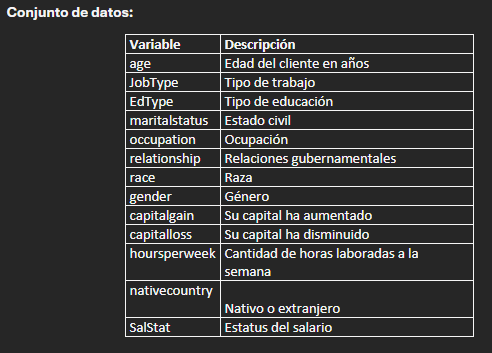

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('datos_caso_5.csv')
data.head()

,age,JobType,EdType,maritalstatus,occupation,relationship,race,gender,capitalgain,capitalloss,hoursperweek,nativecountry,SalStat
0,45,Private,HS-grad,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,28,United-States,"less than or equal to 50,000"
1,24,Federal-gov,HS-grad,Never-married,Armed-Forces,Own-child,White,Male,0,0,40,United-States,"less than or equal to 50,000"
2,44,Private,Some-college,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,"greater than 50,000"
3,27,Private,9th,Never-married,Craft-repair,Other-relative,White,Male,0,0,40,Mexico,"less than or equal to 50,000"
4,20,Private,Some-college,Never-married,Sales,Not-in-family,White,Male,0,0,35,United-States,"less than or equal to 50,000"


## **5. Entendimiento de los Datos**

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31978 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            31978 non-null  int64 
 1   JobType        31978 non-null  object
 2   EdType         31978 non-null  object
 3   maritalstatus  31978 non-null  object
 4   occupation     31978 non-null  object
 5   relationship   31978 non-null  object
 6   race           31978 non-null  object
 7   gender         31978 non-null  object
 8   capitalgain    31978 non-null  int64 
 9   capitalloss    31978 non-null  int64 
 10  hoursperweek   31978 non-null  int64 
 11  nativecountry  31978 non-null  object
 12  SalStat        31978 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


Vemos del .info() que los datos parecen estar completos y por tanto no hay nulos explicitos.

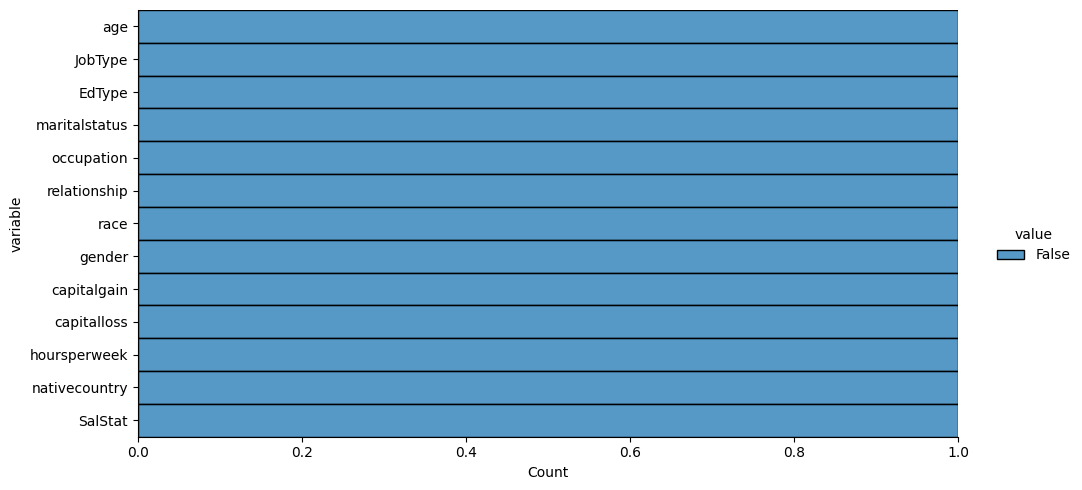

In [15]:
data.isnull().melt().pipe(lambda df: sns.displot(data=df, y='variable',hue='value',multiple='fill',aspect=2))

<function matplotlib.pyplot.show(close=None, block=None)>

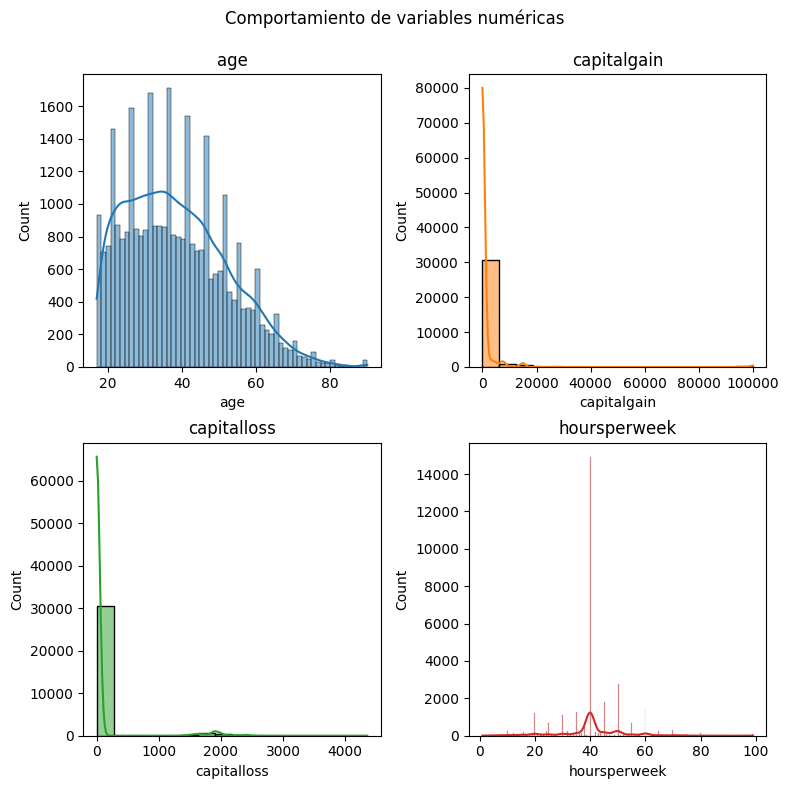

In [16]:
#Gráficos de Histogramas de Frecuencias
fig, ax = plt.subplots(2,2,figsize=(8,8))
ax = ax.flat
num_col = data.select_dtypes(include={'int64','float64'}).columns
for i, col in enumerate(num_col):
    sns.histplot(data=data, x=col, kde=True,
                 color = (list(plt.rcParams['axes.prop_cycle'])*7)[i]['color'],
                 ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de variables numéricas')
plt.show



In [17]:
data.describe()

,age,capitalgain,capitalloss,hoursperweek
count,31978.000000,31978.000000,31978.000000,31978.000000
mean,38.579023,1064.360623,86.739352,40.417850
std,13.662085,7298.596271,401.594301,12.345285
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


No hay que hacer ninguna conversion a string

<function matplotlib.pyplot.show(close=None, block=None)>

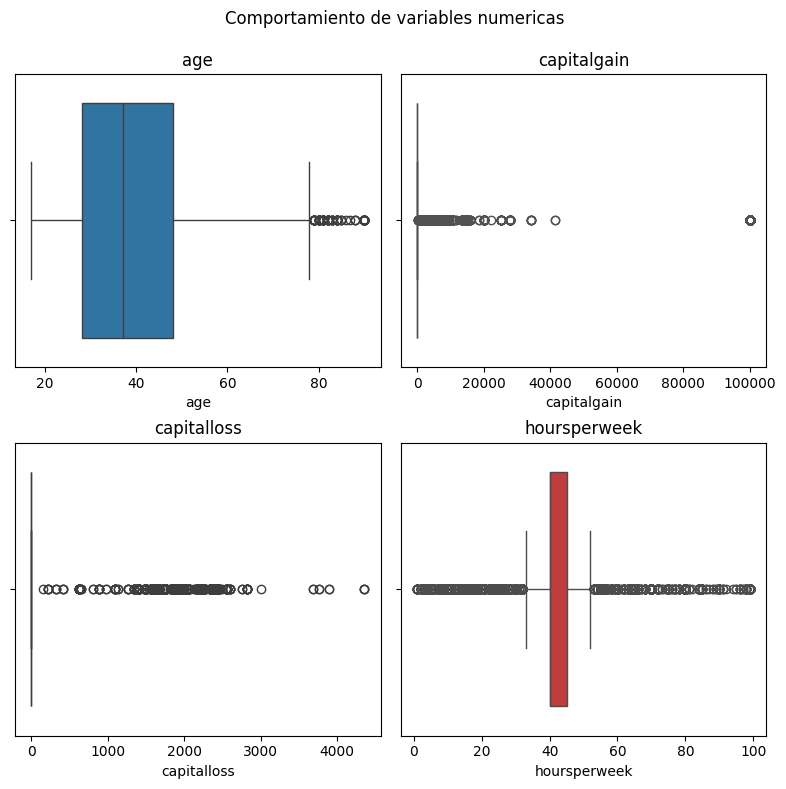

In [18]:
fig, ax = plt.subplots(2,2,figsize = (8,8))
ax = ax.flat
num_col = data.select_dtypes(include={'int64','float64'}).columns
for i, col in enumerate(num_col):
    sns.boxplot(data = data, x = col,
    color = (list(plt.rcParams['axes.prop_cycle'])*7)[i]['color'], 
    ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de variables numericas')
plt.show

Todos los valores atípicos son naturales, entonces ni hacemos ventaneo ni transformamos a nulos.

In [19]:
data.describe(include=['object'])

,JobType,EdType,maritalstatus,occupation,relationship,race,gender,nativecountry,SalStat
count,31978,31978,31978,31978,31978,31978,31978,31978,31978
unique,9,16,7,15,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,"less than or equal to 50,000"
freq,22286,10368,14692,4038,12947,27430,21370,29170,24283


In [20]:
data.JobType.value_counts()

JobType
 Private             22286
 Self-emp-not-inc     2499
 Local-gov            2067
 ?                    1809
 State-gov            1279
 Self-emp-inc         1074
 Federal-gov           943
 Without-pay            14
 Never-worked            7
Name: count, dtype: int64

In [21]:
data.occupation.value_counts()

occupation
 Prof-specialty       4038
 Craft-repair         4030
 Exec-managerial      3992
 Adm-clerical         3721
 Sales                3584
 Other-service        3212
 Machine-op-inspct    1966
 ?                    1816
 Transport-moving     1572
 Handlers-cleaners    1350
 Farming-fishing       989
 Tech-support          912
 Protective-serv       644
 Priv-house-serv       143
 Armed-Forces            9
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

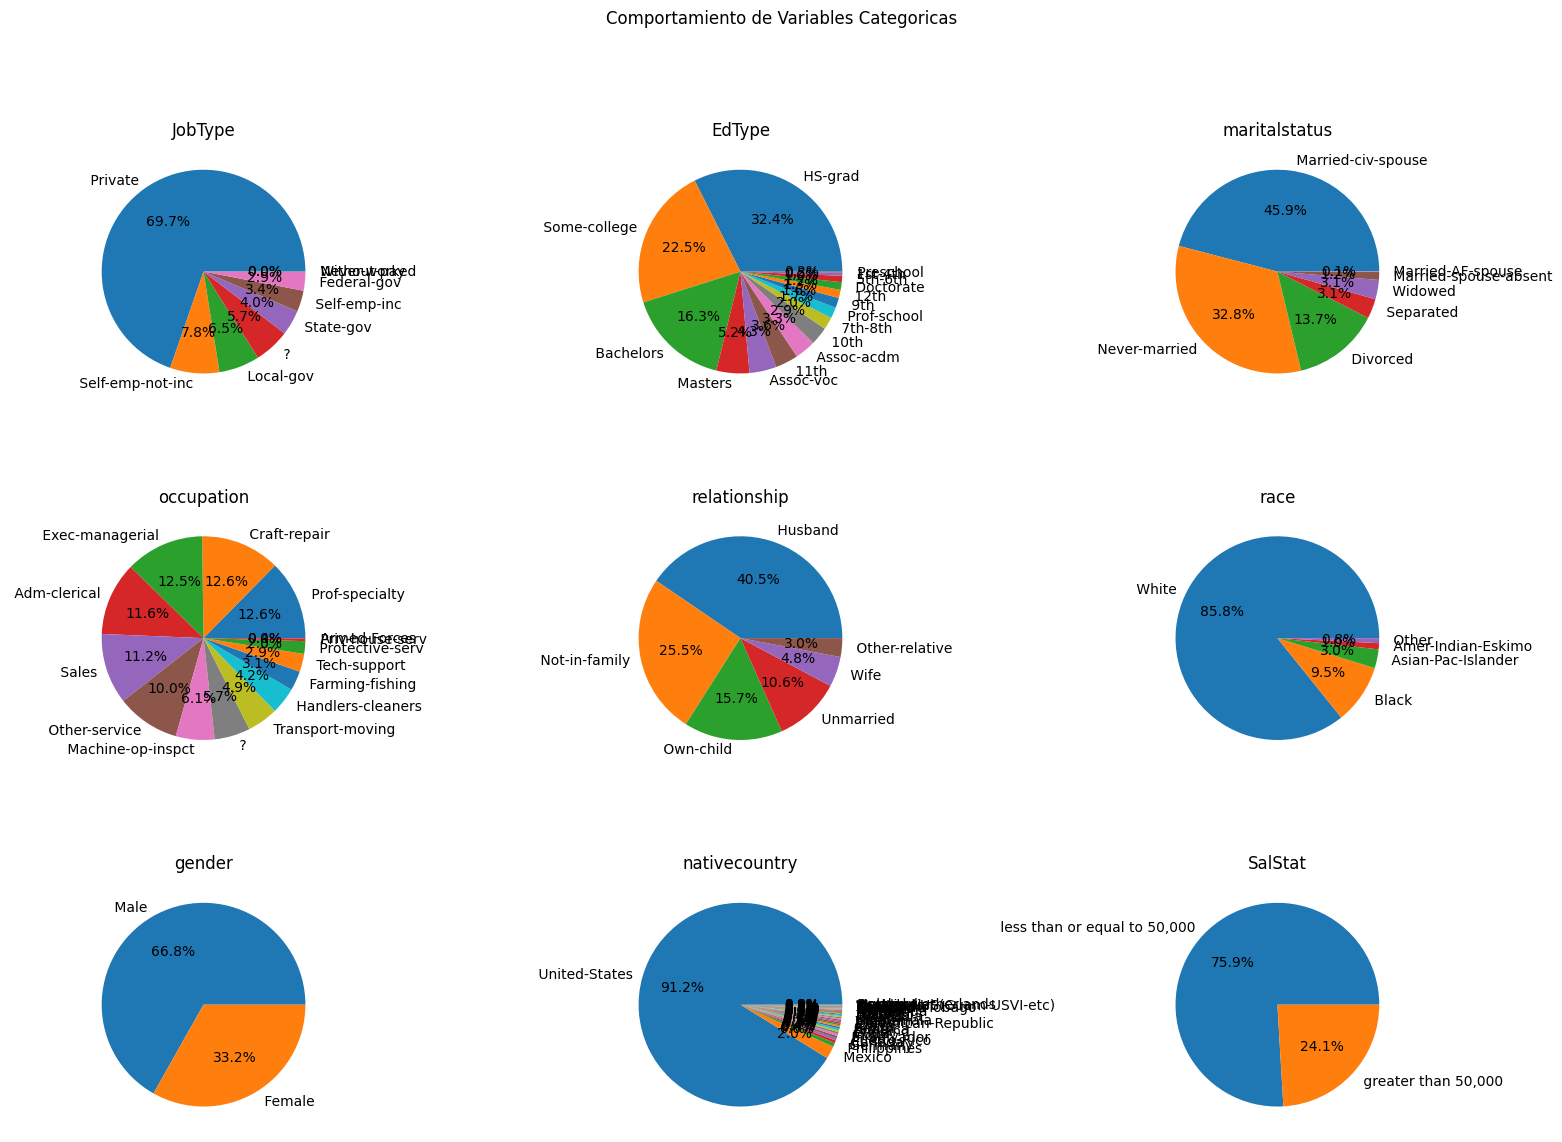

In [22]:
# Gráficos de Torta para variables categoricas
fig, ax = plt.subplots(3,3,figsize = (15,12))
ax = ax.flat
cat_col = data.select_dtypes(include={'object'}).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = "%0.1f%%")
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Categoricas')
plt.show


-  Ignoramos las variables con desbalance mayor a 80% (`nativecountry` y `race`).
- Y balanceamos la y (`SalStat`)
- Tenemos que tener en cuenta otra cosa importante, y es que tanto `JobType` como `occupation` tienen una categoría "?" que es un nulo implicito, entonces hay que transformarlo en explicito.

In [24]:
data.JobType = data.JobType.replace({' ?': np.nan})
data.occupation = data.occupation.replace({' ?': np.nan})
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31978 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            31978 non-null  int64 
 1   JobType        30169 non-null  object
 2   EdType         31978 non-null  object
 3   maritalstatus  31978 non-null  object
 4   occupation     30162 non-null  object
 5   relationship   31978 non-null  object
 6   race           31978 non-null  object
 7   gender         31978 non-null  object
 8   capitalgain    31978 non-null  int64 
 9   capitalloss    31978 non-null  int64 
 10  hoursperweek   31978 non-null  int64 
 11  nativecountry  31978 non-null  object
 12  SalStat        31978 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


In [25]:
data_clean = data.copy()
data_clean.dropna(inplace=True)
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            30162 non-null  int64 
 1   JobType        30162 non-null  object
 2   EdType         30162 non-null  object
 3   maritalstatus  30162 non-null  object
 4   occupation     30162 non-null  object
 5   relationship   30162 non-null  object
 6   race           30162 non-null  object
 7   gender         30162 non-null  object
 8   capitalgain    30162 non-null  int64 
 9   capitalloss    30162 non-null  int64 
 10  hoursperweek   30162 non-null  int64 
 11  nativecountry  30162 non-null  object
 12  SalStat        30162 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


In [26]:
(31978-30162)/31978 *100

5.678904246669585

Sin embargo, vemos que no hay que hacer imputación de datos nulos porque si eliminamos esos datos, perdemos solo aproximadamente 5.6789% de los datos, que es menor al 10% permitido para eliminar registros.

In [27]:
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            30162 non-null  int64 
 1   JobType        30162 non-null  object
 2   EdType         30162 non-null  object
 3   maritalstatus  30162 non-null  object
 4   occupation     30162 non-null  object
 5   relationship   30162 non-null  object
 6   race           30162 non-null  object
 7   gender         30162 non-null  object
 8   capitalgain    30162 non-null  int64 
 9   capitalloss    30162 non-null  int64 
 10  hoursperweek   30162 non-null  int64 
 11  nativecountry  30162 non-null  object
 12  SalStat        30162 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


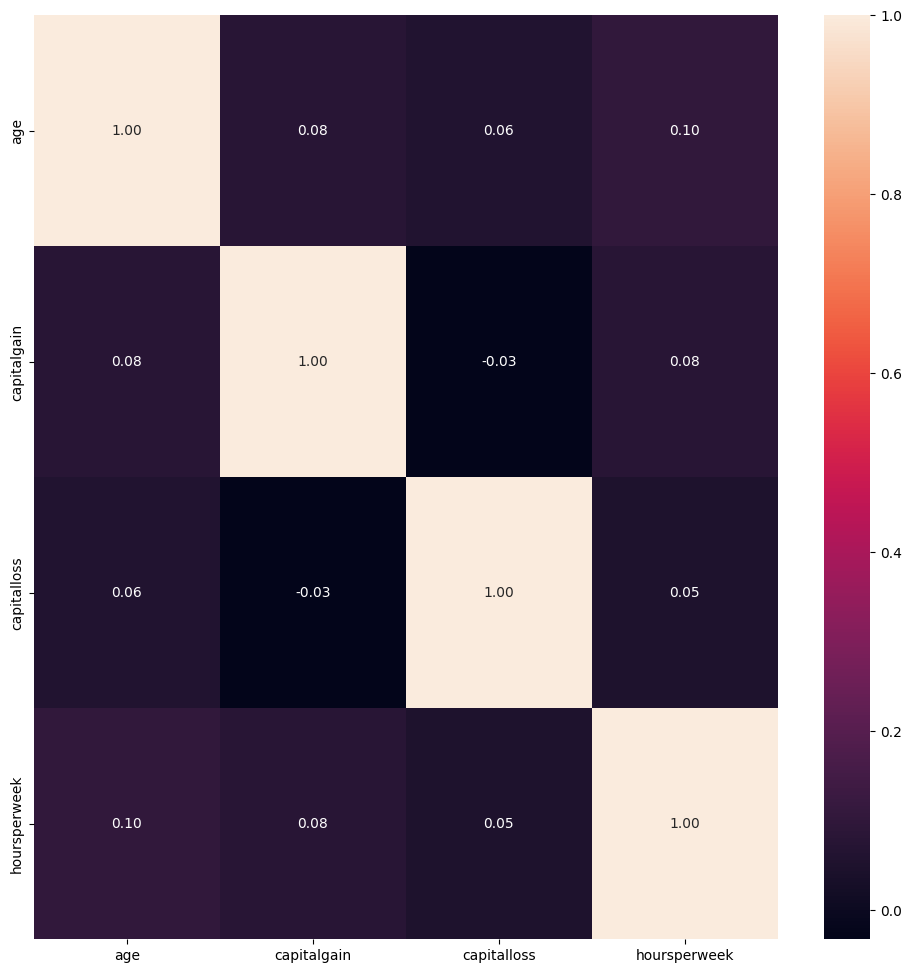

In [28]:
plt.figure(figsize = (12,12))
sns.heatmap(data = data.corr(numeric_only=True),annot=True, fmt='0.2f')
plt.show()

Todas las variables presentan relación nula.
No hay riesgo de multicolinealidad.

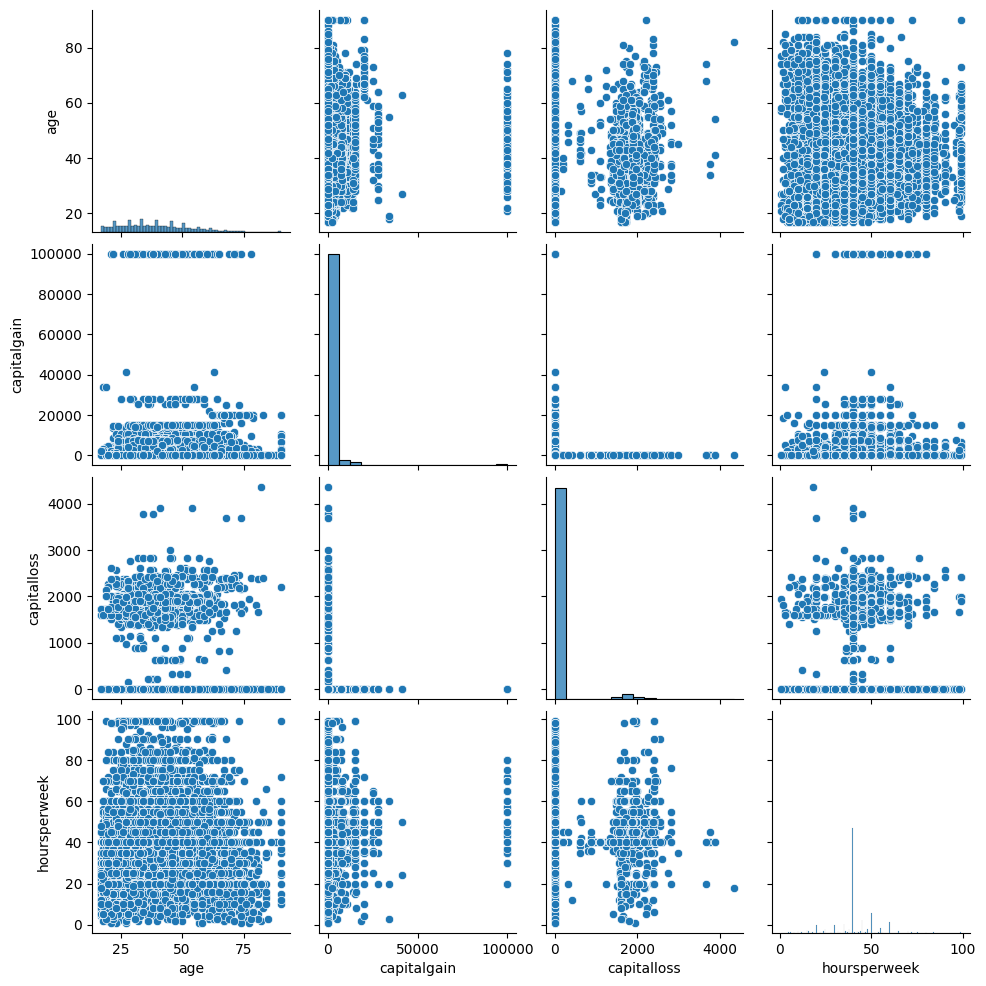

In [29]:
sns.pairplot(data=data)

## **6. Preparación de los Datos**
- Ignorar las variables poco representativas 
- Balancear la variable y
- Transformar las variables numéricas y categóricas
- Separar en conjuntos de entrenamiento y validación

In [30]:
data_mod = data.drop(columns=['nativecountry','race'])

In [31]:
data_mod.SalStat.unique()

array([' less than or equal to 50,000', ' greater than 50,000'],
      dtype=object)

In [32]:
data_greater = data_mod[data_mod['SalStat']==' greater than 50,000']
data_lower = data_mod[data_mod['SalStat']==' less than or equal to 50,000']

print(f'El tamaño de la clase greater than 50000 es: {data_greater.shape}\nEl tamaño de la clase less than or equal to 50000 es {data_lower.shape}')

El tamaño de la clase greater than 50000 es: (7508, 11)
El tamaño de la clase less than or equal to 50000 es (22654, 11)


In [33]:
data_greater_re = data_greater.sample(data_lower.shape[0], replace=True)
data_balanced = pd.concat([data_lower,data_greater_re])
data_balanced.reset_index(drop=True, inplace=True)
data_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45308 entries, 0 to 45307
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            45308 non-null  int64 
 1   JobType        45308 non-null  object
 2   EdType         45308 non-null  object
 3   maritalstatus  45308 non-null  object
 4   occupation     45308 non-null  object
 5   relationship   45308 non-null  object
 6   gender         45308 non-null  object
 7   capitalgain    45308 non-null  int64 
 8   capitalloss    45308 non-null  int64 
 9   hoursperweek   45308 non-null  int64 
 10  SalStat        45308 non-null  object
dtypes: int64(4), object(7)
memory usage: 3.8+ MB


<function matplotlib.pyplot.show(close=None, block=None)>

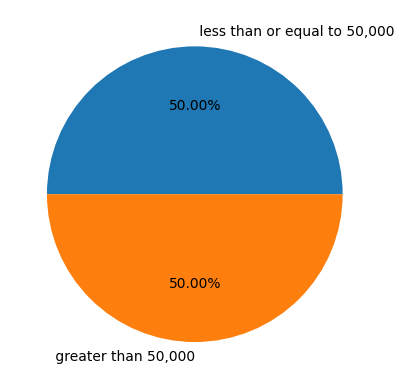

In [34]:
plt.pie(x=data_balanced.SalStat.value_counts(), labels=data.SalStat.value_counts().index, autopct = '%0.2f%%')
plt.show

Ya la variable objetivo y está balanceada.

In [35]:
data_x = data_balanced.copy()
data_x.drop(columns='SalStat', inplace=True)
data_y = data_balanced[['SalStat']]

In [22]:
data_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45322 entries, 0 to 45321
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            45322 non-null  int64 
 1   JobType        45322 non-null  object
 2   EdType         45322 non-null  object
 3   maritalstatus  45322 non-null  object
 4   occupation     45322 non-null  object
 5   relationship   45322 non-null  object
 6   gender         45322 non-null  object
 7   capitalgain    45322 non-null  int64 
 8   capitalloss    45322 non-null  int64 
 9   hoursperweek   45322 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 3.5+ MB


In [36]:
data_y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45308 entries, 0 to 45307
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   SalStat  45308 non-null  object
dtypes: object(1)
memory usage: 354.1+ KB


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [38]:
num_cols = data_x.select_dtypes(include={'int64','float64'}).columns.to_list()
cat_cols = data_x.select_dtypes(include={'object'}).columns.to_list()
num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder(sparse_output=False))])
preprocessor = ColumnTransformer(transformers=[('num',num_transformer,num_cols),('cat',cat_transformer,cat_cols)], remainder='passthrough')
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [39]:
data_pre = preprocessor.fit_transform(data_x)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)
labels = np.concatenate([num_cols, cod_cat])
data_pro = pd.DataFrame(data_pre, columns=labels)
data_pro.head()

,age,capitalgain,capitalloss,hoursperweek,JobType_ Federal-gov,JobType_ Local-gov,JobType_ Private,JobType_ Self-emp-inc,JobType_ Self-emp-not-inc,JobType_ State-gov,...,occupation_ Tech-support,occupation_ Transport-moving,relationship_ Husband,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,gender_ Female,gender_ Male
0,0.383562,0.0,0.0,0.275510,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.095890,0.0,0.0,0.397959,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.136986,0.0,0.0,0.397959,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.041096,0.0,0.0,0.346939,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.369863,0.0,0.0,0.397959,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


Usamos OneHotEncoder para codificar las variables categoricas porque ninguna pasa del limite establecido.

In [40]:
data_y

,SalStat
0,"less than or equal to 50,000"
1,"less than or equal to 50,000"
2,"less than or equal to 50,000"
3,"less than or equal to 50,000"
4,"less than or equal to 50,000"
...,...
45303,"greater than 50,000"
45304,"greater than 50,000"
45305,"greater than 50,000"
45306,"greater than 50,000"


In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_pro,data_y,train_size=0.7, random_state=123)
print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape}{y_train.shape}\nEl tamaño del conjunto de validación es: {X_test.shape}{y_test.shape}')

El tamaño del conjunto de entrenamiento es: (31715, 56)(31715, 1)
El tamaño del conjunto de validación es: (13593, 56)(13593, 1)


<function matplotlib.pyplot.show(close=None, block=None)>

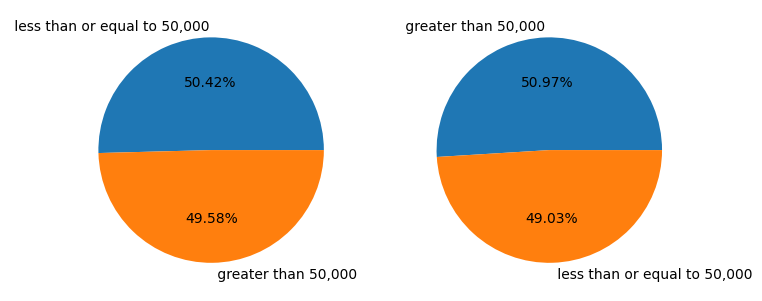

In [42]:
fig, ax = plt.subplots(1,2,figsize=(8,8))
ax[0].pie(x=y_train.SalStat.value_counts(), labels= y_train.SalStat.value_counts().index, autopct = '%0.2f%%')
ax[1].pie(x=y_test.SalStat.value_counts(), labels=y_test.SalStat.value_counts().index, autopct = '%0.2f%%')
plt.show

## **7. Modelado de Datos**
- Regresión Lógistica
- K Vecinos Más Cercanos
- Máquina de Soporte Vectorial
- Árbol de Decisión
- Extra Tree Classifier
- Random Forest
- Adaptative Boosting
- Gradient Boosting
- Red Neuronal Artificial

In [43]:
import warnings
warnings.filterwarnings('ignore')

### Regresión Logistica

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
model_1 = LogisticRegression(solver='saga', random_state=123)
param_grid = {'penalty':['l1','l2','elasticnet'], 'C':[0.001,0.01,0.1,1,10,100,1000]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
clf_1 = GridSearchCV(estimator=model_1, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_1.fit(X_train, y_train)

,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [45]:
validation = pd.concat([pd.DataFrame(clf_1.cv_results_['params']),
                        pd.DataFrame(clf_1.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,C,penalty,F1_score
9,1.000,l1,0.818400
12,10.000,l1,0.818341
16,100.000,l2,0.818340
13,10.000,l2,0.818333
15,100.000,l1,0.818309
18,1000.000,l1,0.818309
19,1000.000,l2,0.818309
6,0.100,l1,0.816738
10,1.000,l2,0.816360
7,0.100,l2,0.810126


### K Vecinos Más Cercanos

In [46]:
from sklearn.neighbors import KNeighborsClassifier
model_2 = KNeighborsClassifier()
param_grid = {'n_neighbors':[3,5,9,7,11,15,101],'p':[1,2]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
clf_2 = GridSearchCV(estimator=model_2, param_grid = param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_2.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [47]:
validation = pd.concat([pd.DataFrame(clf_2.cv_results_['params']),
                        pd.DataFrame(clf_2.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,n_neighbors,p,F1_score
0,3,1,0.834349
1,3,2,0.833032
3,5,2,0.821124
2,5,1,0.821107
7,7,2,0.817275
6,7,1,0.816522
5,9,2,0.812851
4,9,1,0.812293
8,11,1,0.810901
9,11,2,0.809900


### Máquina de Soporte Vectorial

In [48]:
from sklearn.svm import SVC
model_3 = SVC(random_state = 123)
param_grid = {'C':[0.001,0.01,0.1,10,100], "kernel":['poly','linear','rbf','sigmoid'],'degree':[2,3]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state = 123)
clf_3 = GridSearchCV(estimator=model_3, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_3.fit(X_train, y_train)

,estimator,SVC(random_state=123)
,param_grid,"{'C': [0.001, 0.01, ...], 'degree': [2, 3], 'kernel': ['poly', 'linear', ...]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [49]:
validation = pd.concat([pd.DataFrame(clf_3.cv_results_['params']),
                        pd.DataFrame(clf_3.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,C,degree,kernel,F1_score
38,100.000,3,rbf,0.842072
34,100.000,2,rbf,0.842072
36,100.000,3,poly,0.838506
30,10.000,3,rbf,0.835642
26,10.000,2,rbf,0.835642
28,10.000,3,poly,0.835298
32,100.000,2,poly,0.828930
24,10.000,2,poly,0.823297
29,10.000,3,linear,0.810191
25,10.000,2,linear,0.810191


### Árbol de Decisión 

Profundidad del árbol: 48
Número de hojas: 4421


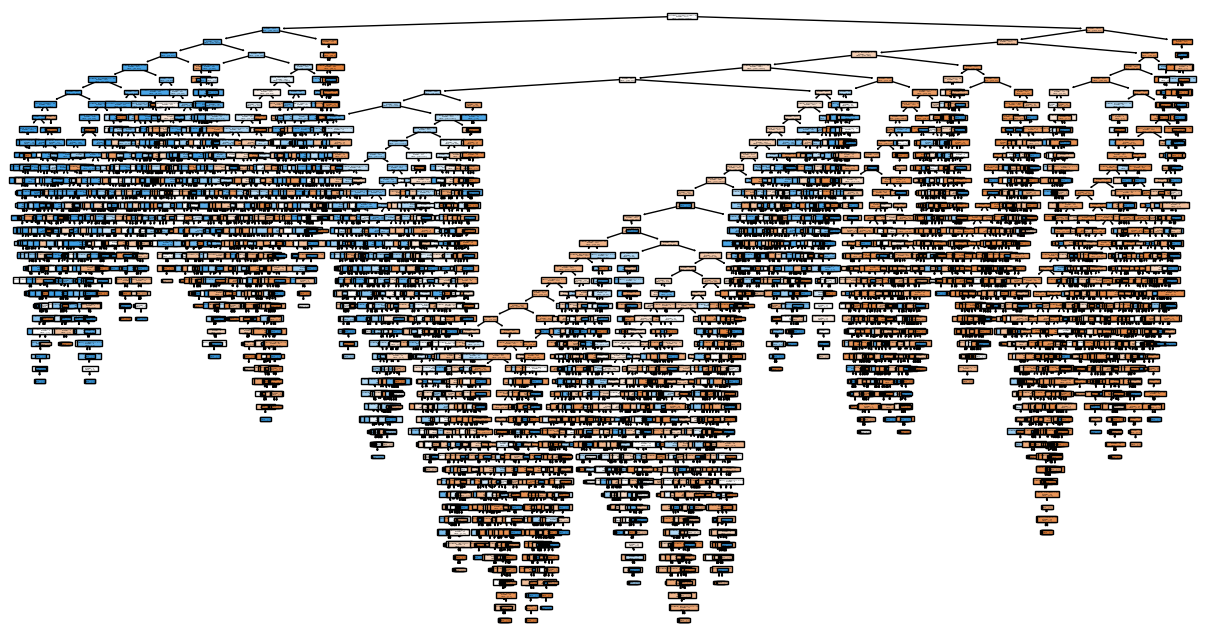

In [50]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
model_tree = DecisionTreeClassifier(random_state = 123)
model_tree.fit(X_train, y_train)
print(f'Profundidad del árbol: {model_tree.get_depth()}\nNúmero de hojas: {model_tree.get_n_leaves()}')
fig, ax = plt.subplots(figsize=(15,8))
plot = plot_tree(decision_tree = model_tree, feature_names = labels, filled = True, impurity = False, ax=ax) #gini por defecto

In [ ]:
model_4 = DecisionTreeClassifier(random_state=123)
param_grid = {'criterion':['entropy','gini','log_loss'],'max_depth':[5,10,15,30,48],'max_leaf_nodes':[100,1000,2000,3000,4421],'min_samples_split':[2,4,6]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state = 123)
clf_4 = GridSearchCV(estimator=model_4, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_4.fit(X_train, y_train)

,estimator,DecisionTreeC...dom_state=123)
,param_grid,"{'criterion': ['entrophy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [5, 10, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [52]:
validation = pd.concat([pd.DataFrame(clf_4.cv_results_['params']),
                        pd.DataFrame(clf_4.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,F1_score
177,gini,48,4421,2,0.880779
267,log_loss,48,4421,2,0.879539
178,gini,48,4421,4,0.873049
268,log_loss,48,4421,4,0.871986
269,log_loss,48,4421,6,0.866410
...,...,...,...,...,...
85,entrophy,48,200,4,NaN
86,entrophy,48,200,6,NaN
87,entrophy,48,4421,2,NaN
88,entrophy,48,4421,4,NaN


### Ensamble
1. ExtraTreeClassifier (stacking)

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
model_5 = ExtraTreesClassifier(random_state=123)
param_grid = {
    'criterion':['entropy','gini','log_loss'], 
    'max_depth':[5,10,15,30,48], 
    'max_leaf_nodes':[100,1000,2000,3000,4421],
    'min_samples_split':[2,4,6],
    'n_estimators':[100,200,400,500]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
clf_5 = GridSearchCV(estimator=model_5, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_5.fit(X_train,y_train)


,estimator,ExtraTreesCla...dom_state=123)
,param_grid,"{'criterion': ['entrophy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [5, 10, ...], 'min_samples_split': [2, 4, ...], ...}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [55]:
validation = pd.concat([pd.DataFrame(clf_5.cv_results_['params']),
                        pd.DataFrame(clf_5.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,n_estimators,F1_score
709,gini,48,4421,2,200,0.888283
710,gini,48,4421,2,400,0.888059
708,gini,48,4421,2,100,0.887992
1071,log_loss,48,4421,2,500,0.887672
711,gini,48,4421,2,500,0.887644
...,...,...,...,...,...,...
355,entrophy,48,4421,4,500,NaN
356,entrophy,48,4421,6,100,NaN
357,entrophy,48,4421,6,200,NaN
358,entrophy,48,4421,6,400,NaN


2. RandomForestClassifier (Bagging)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model_6 = RandomForestClassifier(random_state = 123)
param_grid = {'criterion':['entrophy','gini','log_loss'],
              'max_depth':[5,10,15,30,48],
              'max_leaf_nodes':[100,1000,2000,3000,4421],
              'min_samples_split':[2,4,6],
              'n_estimators':[100,200,400,500]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
clf_6 = GridSearchCV(estimator=model_6, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_6.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_6.cv_results_['params']),
                        pd.DataFrame(clf_6.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

3. AdaptativeBoostingClassifier (Boosting)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model_7 = AdaBoostClassifier(random_state = 123)
param_grid = {'learning_rate':[0.01,0.1,1,10,100], "n_estimators":[100,200,300,400]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state = 123)
clf_7 = GridSearchCV(estimator=model_7, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_7.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_7.cv_results_['params']),
                        pd.DataFrame(clf_7.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

4. GradientBoostingClassifier (Boosting)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
model_8 = GradientBoostingClassifier(random_state=123)
param_grid = {'criterion':['fried,am_mse','squared_error'],
                           'max_depth':[10,15,30,48],
                           'max_leaf_nodes':[1000,2000,None],
                           'min_samples_split':[2,3],
                           'n_estimators':[100,200,300,400]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
clf_8 = RandomizedSearchCV(estimator=model_8, param_distributions=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, n_iter=48)
clf_8.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_8.cv_results_['params']),
                        pd.DataFrame(clf_8.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)